# EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

In this assignment, you will explore land use and land cover (LULC) classification, comparing traditional machine learning and deep learning approaches. You will work with the EuroSAT dataset to implement and evaluate various classification models, from simple SVMs to complex deep learning architectures.

## Submission Guidelines

**All assignments must be completed in groups of 2-3 students.** One member of the group should submit on behalf of everyone, making sure to include all group members' names at the top of the notebook.

Your assignment should be submitted via a pull request to the main branch of this repository. Please make sure it is in the `assignments` subdirectory, titled `eurosat.ipynb`, with any additional files included in a subfolder named `eurosat_files`. Additionally:
- Your notebook must contain the complete assignment instructions, followed by the relevant code chunks
- Your notebook must include group members' names and submission date
- All code must be well-formatted with appropriate code chunks (no overly long code blocks)
- All code must be linted and formatted using [`ruff`](https://docs.astral.sh/ruff/) before submission



## 1. Data Loading, Processing, and Exploration

### 1.1 Data Preparation

Visit [the EuroSAT data description page](https://github.com/phelber/eurosat) and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.


In [2]:
# imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# image handling
from PIL import Image
from skimage.color import rgb2gray

#sk learn import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)


In [3]:
# load data
DATA_DIR = "./EuroSAT_RGB"
IMG_SIZE = 64
x = []
y = []
class_names = []


for label, class_name in enumerate(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    
    if not os.path.isdir(class_path):
        continue
        
    class_names.append(class_name)
    
    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)
        
        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(img)
            
            x.append(img_array)
            y.append(label)
            
        except Exception as e:
            print(f"Skipping {img_path}: {e}")



### EDA

In [4]:
# shape exploration
x = np.array(x)
y = np.array(y)


print("Shape of x:", x.shape)
print("Shape of y:", y.shape)
print("Classes:", class_names)

Shape of x: (27000, 64, 64, 3)
Shape of y: (27000,)
Classes: ['Forest', 'River', 'Highway', 'AnnualCrop', 'SeaLake', 'HerbaceousVegetation', 'Industrial', 'Residential', 'PermanentCrop', 'Pasture']


In [5]:
# class counts
counts = pd.Series(y).value_counts().sort_index()

class_dist = pd.DataFrame({
    "Class": class_names,
    "Count": counts.values
})

print(class_dist)

                  Class  Count
0                Forest   3000
1                 River   2500
2               Highway   2500
3            AnnualCrop   3000
4               SeaLake   3000
5  HerbaceousVegetation   3000
6            Industrial   2500
7           Residential   3000
8         PermanentCrop   2500
9               Pasture   2000


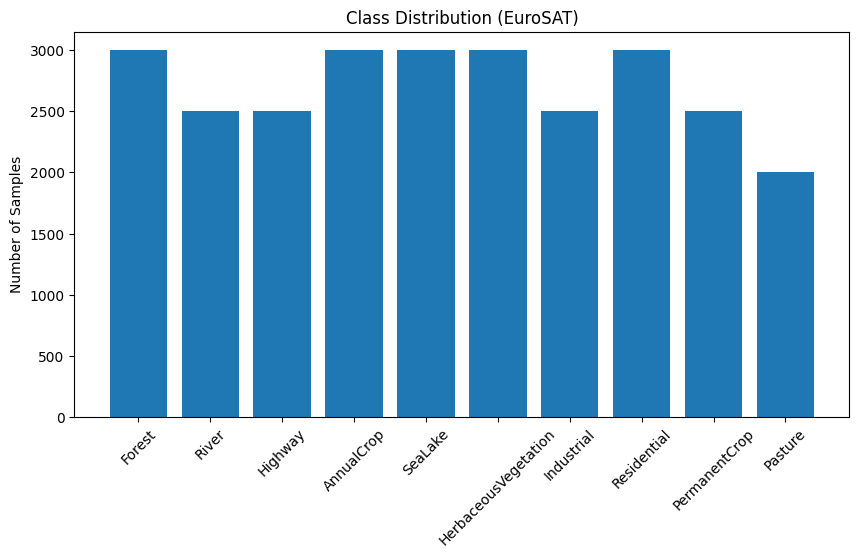

In [6]:
# class counts histogram

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution (EuroSAT)")
plt.ylabel("Number of Samples")
plt.show()

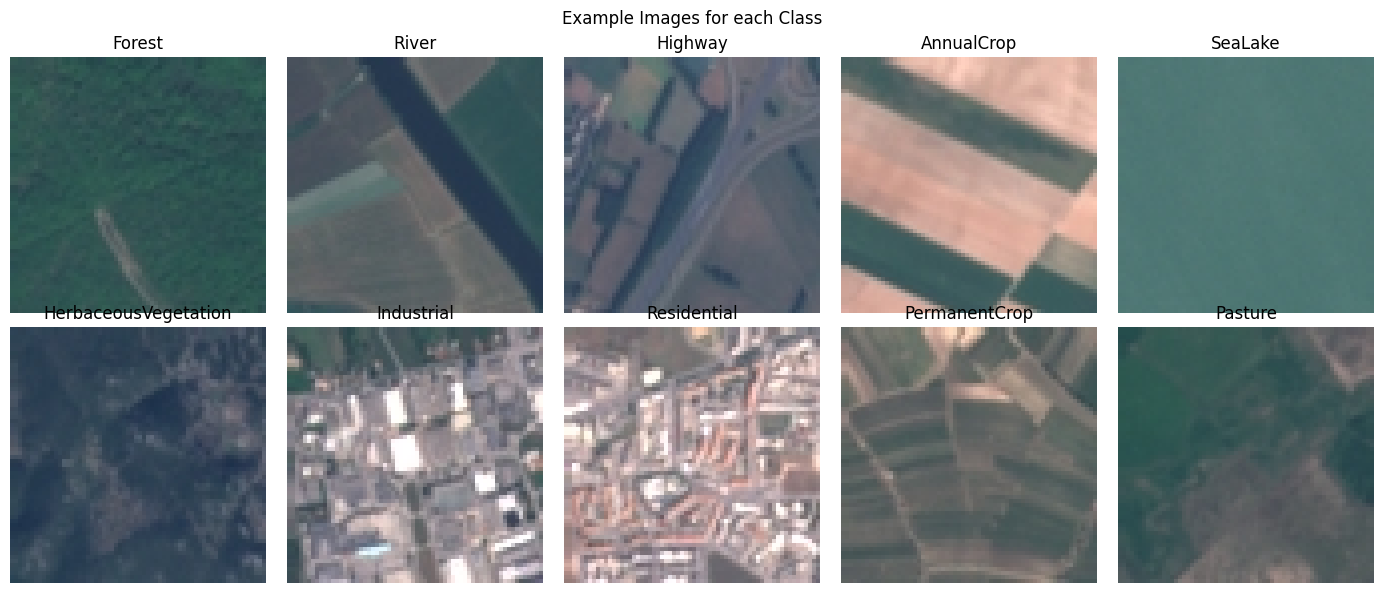

In [7]:
# class images

plt.figure(figsize =(14,6))
for i, class_name in enumerate(class_names):
    idx = np.random.choice(np.where(y == i)[0])

    plt.subplot(2,5,i + 1)
    plt.imshow(x[idx])
    plt.title(class_name)
    plt.axis('off')

plt.suptitle("Example Images for each Class")
plt.tight_layout()
plt.show()

In [8]:
# flatten images into 2D arrays
N, H, W, C = x.shape
x_rgb = x.reshape(N, H * W * C).astype(np.float32) / 255.0   # (N, 64*64*3)

print(x_rgb.shape)

(27000, 12288)


In [9]:
# train test split

idx = np.arange(N)

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.4,
    stratify=y,
    random_state=42
)

x_rgb_train = x_rgb[train_idx]
x_rgb_test = x_rgb[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print("\n--- RGB Train/Test Split ---")
print("x_rgb_train:", x_rgb_train.shape)
print("x_rgb_test: ", x_rgb_test.shape)
print("y_train:    ", y_train.shape)
print("y_test:     ", y_test.shape)


--- RGB Train/Test Split ---
x_rgb_train: (16200, 12288)
x_rgb_test:  (10800, 12288)
y_train:     (16200,)
y_test:      (10800,)


In [10]:
# grayscale conversion and train test split

x_gray_img = rgb2gray(x)

print("Grayscale image shape:", x_gray_img.shape)

N, H, W = x_gray_img.shape
x_gray = x_gray_img.reshape(N, H * W)

print("Flattened grayscale shape:", x_gray.shape)

x_gray_train = x_gray[train_idx]
x_gray_test = x_gray[test_idx]

print("\nGrayscale Train/Test Split")
print("x_gray_train:", x_gray_train.shape)
print("x_gray_test: ", x_gray_test.shape)
print("y_train:     ", y_train.shape)
print("y_test:      ", y_test.shape)

Grayscale image shape: (27000, 64, 64)
Flattened grayscale shape: (27000, 4096)

Grayscale Train/Test Split
x_gray_train: (16200, 4096)
x_gray_test:  (10800, 4096)
y_train:      (16200,)
y_test:       (10800,)



### 1.2 Data Augmentation

Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.


In [ ]:
# augmentation: three separate subsets, each with a different transform
rng = np.random.default_rng(42)

# shuffle and split into 3 subsets of 25% each
shuffled = rng.permutation(len(x))
n_sub = int(len(x) * 0.25)

hflip_idx = shuffled[:n_sub]
vflip_idx  = shuffled[n_sub:2 * n_sub]
rot90_idx  = shuffled[2 * n_sub:3 * n_sub]

x_hflip = np.flip(x[hflip_idx], axis=2)
x_vflip = np.flip(x[vflip_idx], axis=1)
x_rot90 = np.rot90(x[rot90_idx], k=1, axes=(1, 2))

x_aug = np.concatenate([x, x_hflip, x_vflip, x_rot90], axis=0)
y_aug = np.concatenate([y, y[hflip_idx], y[vflip_idx], y[rot90_idx]], axis=0)

print(f"Original:        {len(x):,}")
print(f"+ hflip subset:  {len(x_hflip):,}")
print(f"+ vflip subset:  {len(x_vflip):,}")
print(f"+ rot90 subset:  {len(x_rot90):,}")
print(f"Augmented total: {len(x_aug):,}  (~{len(x_aug)/len(x):.1f}x original)")
print(f"x_aug shape: {x_aug.shape}")

Original:        27,000
+ hflip subset:  6,750
+ vflip subset:  6,750
+ rot90 subset:  6,750
Augmented total: 47,250  (~1.8x original)
x_aug shape: (47250, 64, 64, 3)


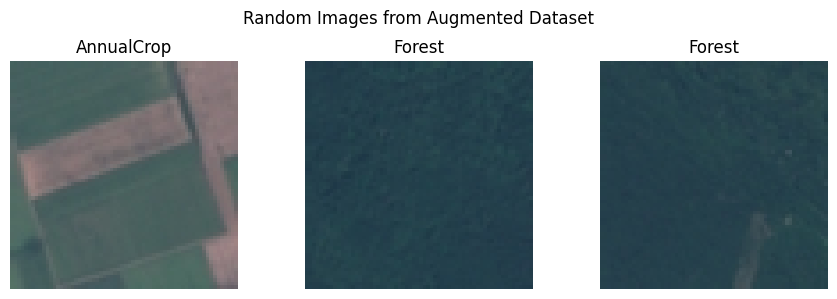

In [16]:
# plot 3 random images from augmented dataset
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
rand_idx = np.random.choice(len(x_aug), 3, replace=False)
for i, idx in enumerate(rand_idx):
    axes[i].imshow(x_aug[idx])
    axes[i].set_title(class_names[y_aug[idx]])
    axes[i].axis("off")
plt.suptitle("Random Images from Augmented Dataset")
plt.tight_layout()
plt.show()

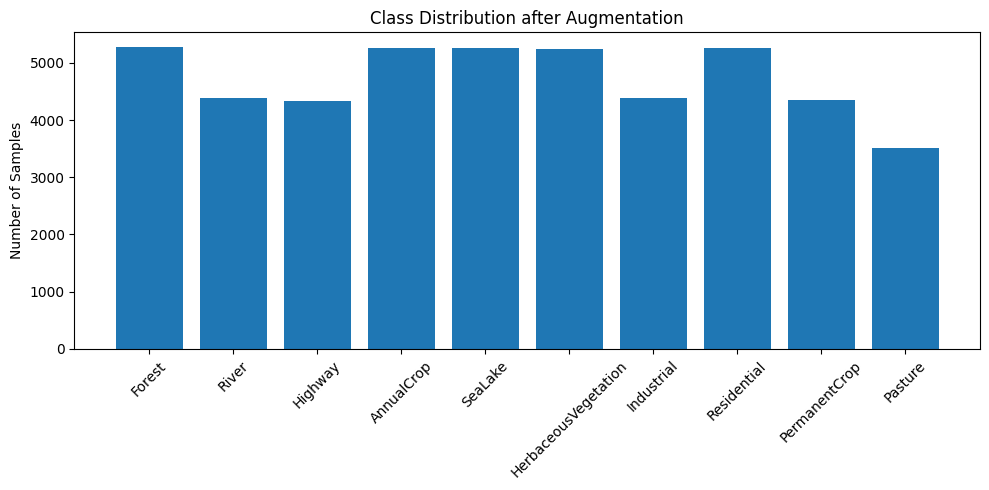

In [ ]:
# class distribution histogram after augmentation
counts_aug = pd.Series(y_aug).value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts_aug)
plt.xticks(rotation=45)
plt.title("Class Distribution after Augmentation")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [ ]:
# redo flatten + grayscale + train/test split using augmented data
# NOTE: overwrites the 1.1 split variables
N_aug = len(x_aug)

x_rgb = x_aug.reshape(N_aug, IMG_SIZE * IMG_SIZE * 3).astype(np.float32) / 255.0

x_gray_img = rgb2gray(x_aug)
x_gray = x_gray_img.reshape(N_aug, IMG_SIZE * IMG_SIZE).astype(np.float32)

aug_idx = np.arange(N_aug)
train_idx, test_idx = train_test_split(
    aug_idx, test_size=0.4, stratify=y_aug, random_state=42
)

x_rgb_train  = x_rgb[train_idx]
x_rgb_test   = x_rgb[test_idx]
x_gray_train = x_gray[train_idx]
x_gray_test  = x_gray[test_idx]
y_train      = y_aug[train_idx]
y_test       = y_aug[test_idx]

print("--- Augmented Train/Test Split ---")
print(f"x_rgb_train:  {x_rgb_train.shape}")
print(f"x_rgb_test:   {x_rgb_test.shape}")
print(f"x_gray_train: {x_gray_train.shape}")
print(f"x_gray_test:  {x_gray_test.shape}")
print(f"y_train:      {y_train.shape}")
print(f"y_test:       {y_test.shape}")

--- Augmented Train/Test Split ---
x_rgb_train:  (28350, 12288)
x_rgb_test:   (18900, 12288)
x_gray_train: (28350, 4096)
x_gray_test:  (18900, 4096)
y_train:      (28350,)
y_test:       (18900,)



## 2. Traditional Machine Learning

For this section, focus on three categories: "Forest (F)", "Residential (R)", and "Industrial (I)". Make sure to subset the grayscale dataset, selecting only these three classes.

### 2.1 Binary Support Vector Machine (Joey)

Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.

### 2.2 Multiclass, Majority-Vote SVM

Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.

### 2.3 Multiclass Random Forest

Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.



## 3. Deep Learning

For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.

### 3.1 Greyscale Images 

For this section, use the same greyscale images that you used in the traditional machine learning section.

#### 3.1.1 Single-Layer Neural Network (Angel)

Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)

#### 3.1.2 Two-Layer Neural Network

Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?

#### 3.1.3 Four-Layer Neural Network with Dropout

Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.

#### 3.1.4 Model Comparison and Ensemble

Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?

### 3.2 RGB Images

For this section, use the original RGB images.

#### 3.2.1 CNN Model (Sujan)

Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?

How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?

#### 3.2.2 Advanced Model

Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?

What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?

### 3.3 Multispectral Images

Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.

How did adding multispectral channels impact your model's performance? Explain the role of additional spectral information in enhancing land cover classification.



## 4. Reflection Questions

What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? How did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?


# EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning
## Submitted by: Joey Cahill, Sujan Kakumanu, Angel Rutherford

In this assignment, you will explore land use and land cover (LULC) classification, comparing traditional machine learning and deep learning approaches. You will work with the EuroSAT dataset to implement and evaluate various classification models, from simple SVMs to complex deep learning architectures.

## Submission Guidelines

**All assignments must be completed in groups of 2-3 students.** One member of the group should submit on behalf of everyone, making sure to include all group members' names at the top of the notebook.

Your assignment should be submitted via a pull request to the main branch of this repository. Please make sure it is in the `assignments` subdirectory, titled `eurosat.ipynb`, with any additional files included in a subfolder named `eurosat_files`. Additionally:
- Your notebook must contain the complete assignment instructions, followed by the relevant code chunks
- Your notebook must include group members' names and submission date
- All code must be well-formatted with appropriate code chunks (no overly long code blocks)
- All code must be linted and formatted using [`ruff`](https://docs.astral.sh/ruff/) before submission

## 1. Data Loading, Processing, and Exploration

### 1.1 Data Preparation

Visit [the EuroSAT data description page](https://github.com/phelber/eurosat) and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

### 1.2 Data Augmentation

Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.

## 2. Traditional Machine Learning

For this section, focus on three categories: "Forest (F)", "Residential (R)", and "Industrial (I)". Make sure to subset the grayscale dataset, selecting only these three classes.

### 2.1 Binary Support Vector Machine

Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.

### 2.2 Multiclass, Majority-Vote SVM

Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.

### 2.3 Multiclass Random Forest

Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.

## 3. Deep Learning

For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.

### 3.1 Greyscale Images

For this section, use the same greyscale images that you used in the traditional machine learning section.

#### 3.1.1 Single-Layer Neural Network

Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)

#### 3.1.2 Two-Layer Neural Network

Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?

#### 3.1.3 Four-Layer Neural Network with Dropout

Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.

#### 3.1.4 Model Comparison and Ensemble

Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?

### 3.2 RGB Images

For this section, use the original RGB images.

#### 3.2.1 CNN Model

Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?

How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?

#### 3.2.2 Advanced Model

Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?

What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?

### 3.3 Multispectral Images

Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.

How did adding multispectral channels impact your model's performance? Explain the role of additional spectral information in enhancing land cover classification.

## 4. Reflection Questions

What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? How did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?

## 5. Rubric (10 points)

| Category                           | Weight | Excellent                                                            | Satisfactory                                   | Unsatisfactory                          |
| ---------------------------------- | ------ | -------------------------------------------------------------------- | ---------------------------------------------- | --------------------------------------- |
| **Analysis & Reflection (60%)**    |
| Model Analysis                     | 2.0    | Deep insights into model behavior; clear understanding of trade-offs | Basic analysis of model performance            | Superficial or missing analysis         |
| Comparative Analysis               | 2.0    | Thorough comparison of approaches; clear rationale for choices       | Basic comparison of models                     | Limited or missing comparisons          |
| Reflection & Future Work           | 2.0    | Thoughtful reflection; clear future directions; learning insights    | Basic reflection with some future ideas        | Superficial or missing reflection       |
| **Technical Implementation (40%)** |
| Data Processing                    | 1.0    | Clean, efficient implementation; thorough preprocessing              | Adequate implementation with minor issues      | Incomplete or flawed implementation     |
| Model Implementation               | 1.0    | Well-structured code; clear architecture; proper documentation       | Functional implementation with basic structure | Poor implementation or missing elements |
| Results & Visualization            | 1.0    | Professional visualizations; clear presentation of results           | Adequate visualizations with minor issues      | Poor or missing visualizations          |
| Code Documentation                 | 1.0    | Clear comments; well-organized; follows best practices               | Basic documentation with minor issues          | Poor or missing documentation           |
